# **Not all samples are created equal : Deep Learning with Importance Sampling**

Angelos Katharopoulos, François Fleuret (2019)

Aujourd'hui, des méthodes de Deep Learning très évoluées et un accès à la data démocratisé permettent d'entraîner des réseaux de neurones de plus en plus complexes. Dans ce cadre-ci, il devient important de prêter attention au temps d'entraînement de tels modèles, qui peut vite devenir considérable.  

Or, au sein d'un ensemble d'entraînement, un grand nombre d'échantillons sont vite apprivoisés par le modèle, qui les classe correctement au bout de quelques epochs seulement. Ils ne lui apprennent ensuite plus rien, mais l'on continue de les faire passer à travers le réseau (forward et backpropagation) à chaque itération, ce qui prend un temps colossal. Il convient donc de vouloir échantillonner nos données en choisissant simplement celles qui vont faire progresser le modèle le plus vite possible, afin d'utiliser bien moins d'échantillons dans la backpropagation du réseau, pour un résultat tout aussi efficace.  

C'est le principe de l'Importance Sampling, décrit dans l'article en question datant de 2019. L'objectif ici sera de trouver une manière intelligente de choisir les échantillons sur lesquels le modèle s'appuiera, en se basant sur le gradient de leur loss (l'écart entre leur valeur prédite et leur valeur réelle).

L'objectif ici sera d'optimiser la vitesse de convergence de notre modèle (vers ses paramètres optimaux), tout en prenant un faible nombre d'échantillons en compte à chaque epoch.  

On note $N$ le nombre d'échantillons présent dans notre set total. La méthode classique consisterait à prendre un batch de $B < N$ échantillons en considération à chaque itération, que l'on passerait au sein du réseau de neurones, puis de se baser sur $b<B$ samples parmi eux choisis de manière uniforme, afin d'optimiser ses paramètres par backpropagation.

Maintenant, si l'on choisit ces samples de manière uniforme, il y a de fortes chances pour que l'on prenne en compte des images simples à classer qui vont peu affecter les paramètres du modèle, ce que l'on veut c'est optimiser les paramètres à l'aide des images qui vont le plus les influencer. La vitesse de convergence vers les paramètres optimaux augmenterait alors. Dans le cas idéal, on prendrait alors tous les $B$ samples pour effectuer la backpropagation, comme ça le réseau a connaissance de tous les échantillons, aussi bien ceux faciles à classer que ceux compliqués, et les paramètres du modèle seraient rapidement optimisés.

Or, cela prend beaucoup de temps, on va donc vouloir regarder moins d'échantillons. On va vouloir sélectionner $b << B$ échantillons, selon une distribution de probabilité bien choisie. On note $p_{i}$ la probabilité que l'échantillon i du batch de taille B soit choisi. Le but de l'article est de nous expliquer comment choisir les $p_{i}$ afin que les échantillons ayant le plus de chances d'être choisis soient ceux qui sont encore les moins bien apprivoisés par le modèle. Ce sont ceux dont la loss est la plus variable (la classification change encore d'une itération à l'autre), i.e. ceux dont le gradient de leur loss est le plus élevé.  

Notant $θ_{t}$ le set de paramètres du réseau de neurones considéré à l'étape t de l'entraînement, on définit la vitesse de convergence de l'entraînement de notre modèle vers le set de paramètres optimal $\theta^*$ comme $S = - \mathbb{E}[ ||\theta_{t+1} - \theta^*||^2 - [[\theta_{t}-\theta^*||^2]$. On définit $I_t$ comme une variable aléatoire représentant l'indice de l'échantillon sélectionné à l'instant t. On pose également $w_i = \frac{1}{Bp_i}$ et $\eta$ le learning rate du modèle, de sorte que pour chaque itération $t$, $\theta_{t+1} = \theta_t - \eta w_{I_t}^{(t)}\nabla_{\theta_t}\mathbf{L}(\Phi(x_{I_t},\theta_t),y_{I_t}) = \theta_t - \eta G_{I_t}$, avec $(x_t,y_t)$ les images et leur classifications à l'itération t. Pour une batch size de b, on mettra à jour $\theta$ en moyennant selon cette formule sur tous les échantillons choisis.

On remarque donc que moins un point va avoir de chances d'être choisi ($p_i → 0$), plus son poids $w_i$ associé sera élevé, ainsi le fait que l'on ne voit pas souvent ce point est compensé par le fait que la fois où on le verra, il influencera fortement la modification des paramètres $\theta$.  

On note $S_{BGD}$ la vitesse de convergence atteinte dans le cas où l'on prend l'intégralité du batch de taille B pour effectuer l'entraînement. Cette vitesse de convergence est la vitesse maximale que l'on pourrait atteindre dans notre cas, le but sera donc de faire en sorte de s'en rapprocher le plus possible. On rappelle que le but est de converger bien plus rapidement vers les paramètres optimaux qu'avec la méthode aléatoire, mais en prenant moins d'échantillons que si l'on prenait tout le batch (comme ça le temps d'exécution d'une itération reste acceptable).  
Après développement de l'expression de S en fonction des expressions des $\theta_t$, on trouve que $S = S_{BGD} - \eta^2 Tr(\mathbb{V}(G_{I_t}))$.

Ainsi, on va vouloir minimiser la variance du gradient de la loss pour se rapprocher de la vitesse optimale, tout en gagnant du temps en prenant bien moins de samples. La problématique ici est que le calcul de la distribution de probabilité minimisant $\mathbb{V}(G_{I_t})$ peut prendre du temps. En effet, le problème d'optimisation que l'on cherche à résoudre ici à pour solution $$p_i^* = \frac{\|\nabla_{\theta} L_i(\theta)\|}{\sum_{j=1}^N \|\nabla_{\theta} L_j(\theta)\|}$$ qui est donc proportionnelle à la norme du gradient de la loss.  
Si l'on doit calculer la norme du gradient de la loss de chaque point à chaque fois, le coût temporel est colossal donc on ne s'y retrouverait pas.  

L'astuce de la méthode présentée ici est de définir les $p_i$ à partir d'une borne supérieure du gradient qui serait plus facile à calculer. En définissant $\Sigma_k$ la fonction d'activation de la couche k notre réseau de neurones, L le nombre de couches du réseau, et $z_{i}^{(k)}$ la valeur en sortie de la couche k avant activation, après calcul on trouve : $$\hat{G}_i = L \rho \| \Sigma_{L}'(z_{i}^{(L)}) \nabla_{x_{i}^{(L)}} \mathbf{L} \|$$, où $\rho$ est une constante d'un échantillon à l'autre.

Mathématiquement, cette borne supérieure revient à regarder l'erreur brute en sortie du réseau. Si le réseau se trompe fort, la norme est grande, donc l'échantillon est important. C'est un calcul instantané qui ne demande pas de remonter tout le réseau, et le calcul de la distribution de probabilité n'est donc plus tant coûteux : $$p_i ∝ \hat{G}_i$$

On va maintenant vouloir évaluer à quel point notre variance a été réduite, par rapport au cas où l'on utiliserait une distribution uniforme pour choisir nos échantillons. Notant $u = \frac{1}{B}$ la distribution uniforme, on a alors :
$$\frac{Tr(\mathbb{V}_u(G_i)) - Tr(\mathbb{V}_p(w_iG_i))}{Tr(\mathbb{V}_u(G_i))} = ... = \frac{1}{\sum{p_i^2}}\|p - u\|^2 = 1 - \frac{1}{\tau}$$
où l'on pose $\tau$ comme étant un paramètre définissant l'incrément de la batch size équivalent à l'usage de cette méthode : $\tau = 2 ⇔$ le petit batch choisi par importance sampling réduit autant la variance du gradient de la loss qu'un batch uniforme deux fois plus grand.  

C'est sur cette grandeur $\tau$ que l'on va se baser pour définir si cela est rentable ou non d'utiliser l'importance sampling.

L'algorithme suivant synthétise donc le principe de l'importance sampling, afin d'entraîner les paramètres du modèle sur un minimum d'images, les plus dures à classer, tout en ne perdant pas trop de temps à calculer tous les gradients de loss pour savoir les identifier.

```
Initialisation de :
  - B la taille du grand batch à partir duquel on classe nos images, et dans lequel on va venir piocher pour optimiser les paramètres du modèle
  - b la taille du mini batch qui va servir à mettre à jour les paramètres du réseau de neurones
  - tau_th le seuil de rentabilité au-delà duquel l'importance sampling sera privilégié (quand tau > tau_th)
  - theta le set de paramètres initiaux du réseau de neurones

Si tau >= tau_th :
  - on choisit B images uniformément
  - on calcule les G^i, borne supérieure du gradient, pour les B images
  - on choisit b images avec la distribution p calculée proportionnellement à G^i
  - On met à jour les paramètres theta, en se basant uniquement sur les b images choisies, pondérées par les poids w_i
  
Si tau < tau_th :
  - SGD classique, on tire directement b samples au hasard, avec pondération w_i = 1
  - on calcule tout de même les importances proortionnelles à G^i pour mettre à jour tau

Mise à jour de tau avec lissage

Répétition jusqu'à convergence
```

Passons maintenant à la démonstration expérimentale de la partie théorique. Nous allons entraîner un réseau de neurones sur un jeu de données afin de faire de la classification d'images, à la fois en choisissant de manière uniforme les échantillons qui vont servir à la backpropagation du réseau, et en utilisant la méthode d'Importance Sampling.  

On regardera alors l'évolution de la loss au fûr et à mesure de l'entraînement, à la fois vis-à-vis du temps d'exécution et du nombre d'itérations. On s'attend à ce que la méthode d'Importance Sampling prenne davantage de temps pour run les itérations, car il y a quand même l'étape de calcul des $\hat{G}_{i}$ qui entre en jeu. En revanche, la loss devrait diminuer plus vite en termes de nombre d'itérations que pour la méthode uniforme.  

On choisit ici d'entraîner un modèle ResNet18 (assez simple), sur le jeu de données CIFAR-100, pris en exemple dans l'article. Notre réseau de neurones est simple, tout comme le jeu de données, ce qui fait que l'on ne s'attend pas à avoir des résultats aussi flagrants que voulus, mais on se limitera à cette configuration pour garder un temps d'entraînement faible.

In [1]:
# Importation des packages nécessaires

import time
import copy
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import numpy as np

In [8]:
# Définition de la classe ImportanceSamplingTrainer, qui implémente la méthode d'Importance Sampling

class ImportanceSamplingTrainer:
    def __init__(self, model, optimizer, B=256, b=32, tau_th=1.2, a_tau=0.9):
        """
        B : Taille du réservoir (le grand échantillon U)
        b : Taille du batch final (le petit échantillon G)
        tau_th : Seuil de rentabilité pour activer l'Importance Sampling
        a_tau : Coefficient de lissage pour la moyenne mobile de tau
        """
        self.model = model
        self.optimizer = optimizer
        self.B = B
        self.b = b
        self.tau_th = tau_th
        self.a_tau = a_tau
        self.tau = 0.0
        self.criterion_none = nn.CrossEntropyLoss(reduction='none')
        self.device = next(model.parameters()).device

    def compute_tau(self, gi):
        """
        Estimation du gain de réduction de variance tau
        """
        numerator = np.sum(gi**2)
        mean_g = np.mean(gi)
        denominator = np.sum((gi - mean_g)**2)

        if denominator == 0:
          return 1.0
        tau_t = 1.0 / (1.0 - (denominator / numerator))
        return tau_t

    def train_one_step(self, dataloader_iter):
        """
        Implémentation d'une étape d'entraînement de l'importance sampling.
        """

        # On lit le dataloader, s'il est vide, on renvoie None pour signaler la fin de l'epoch
        try:
              batch_data = next(dataloader_iter)
        except StopIteration:
            return None, self.tau

        # On envoie les images sur le device
        images_U, labels_U = batch_data
        images_U, labels_U = images_U.to(self.device), labels_U.to(self.device)

        current_B = len(images_U)

        # 1. Si tau est supérieur au seuil tau_th, on va utiliser l'importance sampling
        use_is = self.tau > self.tau_th

        if use_is:
            # IMPORTANCE SAMPLING

            # Calcul de G_hat : Forward pass rapide
            self.model.eval()
            with torch.no_grad():
                outputs_U = self.model(images_U)
                # Approximation : Erreur L2 entre probas et labels
                probs_U = torch.softmax(outputs_U, dim=1)
                one_hot_labels = torch.nn.functional.one_hot(labels_U, num_classes=outputs_U.size(1))
                # gi = borne supérieure du gradient (norme de l'erreur en sortie)
                gi = torch.norm(probs_U - one_hot_labels, p=2, dim=1).cpu().numpy()

            # Sélection de b exemples
            p_sampling = gi / gi.sum()
            actual_b = min(self.b, current_B)
            indices = np.random.choice(current_B, size=actual_b, p=p_sampling, replace=False)

            images_G = images_U[indices]
            labels_G = labels_U[indices]

            # Calcul des poids wi : pour atténuer l'importance des éléments que l'on voit le plus souvent
            wi = 1.0 / (self.B * p_sampling[indices])
            wi = torch.from_numpy(wi).to(self.device).float()
            # Normalisation des poids pour la stabilité numérique
            wi = wi / wi.mean()
            wi = torch.clamp(wi, max=10.0)

        else:
            # MODE UNIFORME
            # On prend juste b exemples au hasard
            images_G = images_U[:self.b]
            labels_G = labels_U[:self.b]
            wi = torch.ones(self.b).to(self.device)

            # On calcule quand même gi pour mettre à jour tau
            self.model.eval()
            with torch.no_grad():
                outputs_G = self.model(images_G)
                probs_G = torch.softmax(outputs_G, dim=1)
                one_hot_labels = torch.nn.functional.one_hot(labels_G, num_classes=outputs_G.size(1))
                gi = torch.norm(probs_G - one_hot_labels, p=2, dim=1).cpu().numpy()


        # Backpropagation sur les b échantillons choisis (mise à jour des poids du réseau)
        self.model.train()
        self.optimizer.zero_grad()
        outputs = self.model(images_G)
        # On applique les poids wi sur la loss de chaque échantillon
        loss = (self.criterion_none(outputs, labels_G) * wi).mean()
        loss.backward()
        self.optimizer.step()

        # 3. Mise à jour de tau par moyenne mobile
        tau_t = self.compute_tau(gi)
        self.tau = self.a_tau * self.tau + (1 - self.a_tau) * tau_t

        return loss.item(), self.tau

In [17]:
# Entraînement du modèle avec le choix des échantillons selon une loi uniforme
def train_uniform_baseline(model_state, steps):
    print("--- Démarrage Baseline Uniforme ---")
    # Récupération du modèle et de l'optimiseur
    model = get_model()
    model.load_state_dict(model_state)
    optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
    criterion = nn.CrossEntropyLoss()

    iter_loader = iter(loader_Uniform)

    times = []
    losses = []
    start_time = time.time()

    model.train()
    # Itérations sur steps epochs
    for step in range(steps):
        try:
            inputs, labels = next(iter_loader)
        except StopIteration:
            iter_loader = iter(loader_Uniform)
            inputs, labels = next(iter_loader)

        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

        # Passage forward dans le réseau
        optimizer.zero_grad()
        outputs = model(inputs)
        # Calcul de la loss et backpropagation
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # Calcul du temps d'exécution à chaque checkpoint
        if step % 10 == 0:
            elapsed = time.time() - start_time
            times.append(elapsed)
            losses.append(loss.item())

        if step % PRINT_EVERY == 0:
            print(f"[Uniforme] Step {step}/{steps} | Loss: {loss.item():.4f} | Temps: {elapsed:.1f}s")

    return times, losses

In [18]:
# Entraînement du modèle avec le choix des échantillons selon l'importance sampling
def train_is_method(model_state, steps):
    print("--- Démarrage Importance Sampling ---")
    # Récupération du modèle et de l'optimiseur
    model = get_model()
    model.load_state_dict(model_state) # Reset poids
    optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

    # Instanciation de l'Importance Sampling Trainer
    trainer = ImportanceSamplingTrainer(model, optimizer, B=B, b=b, tau_th=1.2)
    iter_loader = iter(loader_IS)

    times = []
    losses = []
    start_time = time.time()

    # Itérations sur steps epoches
    for step in range(steps):

        loss, current_tau = trainer.train_one_step(iter_loader)

        # Si loss est None, on arrive à la fin du dataloader
        if loss is None:
            # On reset l'itérateur
            iter_loader = iter(loader_IS)
            # On relance un pas immédiatement pour ne pas perdre l'itération
            loss, current_tau = trainer.train_one_step(iter_loader)

        # Enregistrement des temps
        if step % 10 == 0:
            elapsed = time.time() - start_time
            times.append(elapsed)
            losses.append(loss)

        if step % PRINT_EVERY == 0:
            mode = "IS" if trainer.tau > trainer.tau_th else "Warmup"
            print(f"[Méthode IS] Step {step}/{steps} | Loss: {loss:.4f} | Tau: {trainer.tau:.2f} | Mode: {mode} | Temps: {elapsed:.1f}s")

    return times, losses

In [19]:
# Configuration de l'entraînement (nombre d'échantillons sélectionnés, d'itérations, ...)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
B = 128
b = 64
STEPS = 3000
PRINT_EVERY = 50

# Récupération des données CIFAR-100
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

trainset = torchvision.datasets.CIFAR100(root='./data', train=True, download=True, transform=transform)

# Dataloader pour Importance Sampling (gros batchs B)
loader_IS = torch.utils.data.DataLoader(trainset, batch_size=B, shuffle=True, num_workers=4)

# Dataloader pour échantillonnage uniforme (petits batchs b)
loader_Uniform = torch.utils.data.DataLoader(trainset, batch_size=b, shuffle=True, num_workers=2)

# Définition du modèle ResNet18
def get_model():
    model = models.resnet18(pretrained=False)
    model.fc = nn.Linear(model.fc.in_features, 100)
    return model.to(DEVICE)

# On crée un état initial commun pour l'équité
initial_model = get_model()
initial_state = copy.deepcopy(initial_model.state_dict())

# Entraînement en suivant la méthode uniforme
t_unif, l_unif = train_uniform_baseline(initial_state, STEPS)

# Entraînement en suivant la méthode d'importance sampling
t_is, l_is = train_is_method(initial_state, STEPS)

--- Démarrage Baseline Uniforme ---
[Uniforme] Step 0/3000 | Loss: 4.7091 | Temps: 0.1s
[Uniforme] Step 50/3000 | Loss: 4.5387 | Temps: 1.5s
[Uniforme] Step 100/3000 | Loss: 4.3808 | Temps: 2.9s
[Uniforme] Step 150/3000 | Loss: 4.2612 | Temps: 4.3s
[Uniforme] Step 200/3000 | Loss: 3.8474 | Temps: 6.1s
[Uniforme] Step 250/3000 | Loss: 4.0138 | Temps: 7.6s
[Uniforme] Step 300/3000 | Loss: 3.8737 | Temps: 9.1s
[Uniforme] Step 350/3000 | Loss: 3.6440 | Temps: 10.5s
[Uniforme] Step 400/3000 | Loss: 3.8627 | Temps: 12.0s
[Uniforme] Step 450/3000 | Loss: 3.6061 | Temps: 13.4s
[Uniforme] Step 500/3000 | Loss: 3.5369 | Temps: 14.8s
[Uniforme] Step 550/3000 | Loss: 3.6901 | Temps: 16.3s
[Uniforme] Step 600/3000 | Loss: 3.6257 | Temps: 17.9s
[Uniforme] Step 650/3000 | Loss: 3.7305 | Temps: 19.6s
[Uniforme] Step 700/3000 | Loss: 3.4750 | Temps: 21.1s
[Uniforme] Step 750/3000 | Loss: 3.4319 | Temps: 22.5s
[Uniforme] Step 800/3000 | Loss: 3.2359 | Temps: 24.0s
[Uniforme] Step 850/3000 | Loss: 3.4879

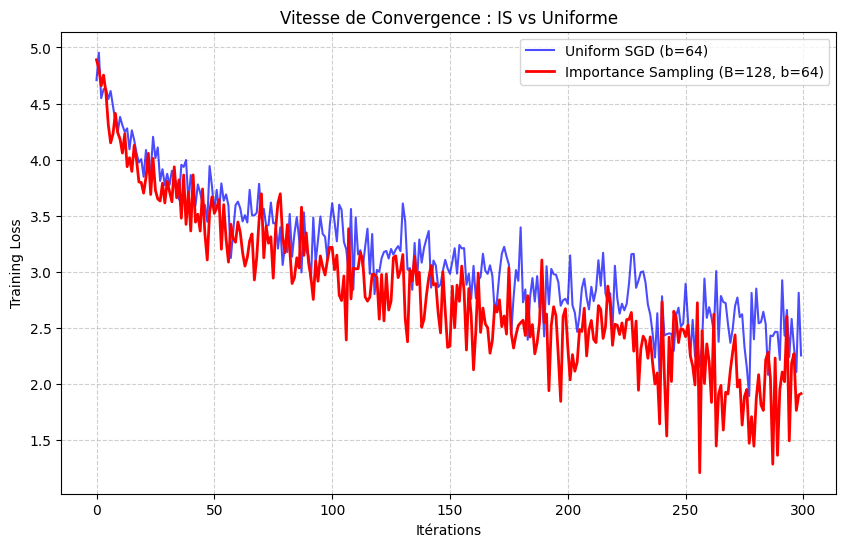

In [20]:
iterations = np.arange(len(l_unif)) * 10

plt.figure(figsize=(10, 6))
plt.plot(iterations, l_unif, label=f'SGD Uniforme (b={b})', alpha=0.7, color='blue')
plt.plot(iterations, l_is, label=f'Importance Sampling (B={B}, b={b})', linewidth=2, color='red')

plt.xlabel('Itérations')
plt.ylabel('Training Loss')
plt.title('Vitesse de Convergence : IS vs Uniforme')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

On observe ici qu'à nombre d'itérations égales, la méthode d'Importance Sampling donne des valeurs de Training Loss assez significativement inférieures à celles obtenues par la méthode "classique". Toutefois, le modèle et le cas présenté ici étant relativement simples, on se doute bien que cet avantage n'est pas assez important pour privilégier l'Importance Sampling, car (cf ci-dessous), le temps d'exécution reste plus long.  

Une itération prend plus de temps à s'exécuter avec l'importance sampling, car il y a besoin de calculer les distributions de probabilité avant de choisir les échantillons d'intérêt. Ainsi, vu qu'ici la méthode classique arrive à produire une loss satisfaisante en assez peu d'itérations, l'intérêt de la méthode d'importance sampling est moindre.

Mais l'on voit bien que pour des modèles plus complexes nécessitant davantage d'itérations, il sera préférable d'utiliser cette méthode, car on pourra alors s'arrêter à bien moins d'itérations et quand même avoir une loss convenable, le gain en nombre d'itérations surpassant alors la perte de temps occasionné par l'usage de l'importance sampling à chaque step.

In [1]:
plt.figure(figsize=(10, 6))
plt.plot(t_unif, l_unif, label=f'SGD Uniforme (b={b})', alpha=0.7, color='blue')
plt.plot(t_is, l_is, label=f'Importance Sampling (B={B}, b={b})', linewidth=2, color='red')

plt.xlabel('Itérations')
plt.ylabel('Training Loss')
plt.title('Vitesse de Convergence : IS vs Uniforme')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

NameError: name 'plt' is not defined